# Permutation Control: Shuffled AI Description RDM Searchlight RSA

Reload the real searchlight result from the AI description CLIP RDM,
run 10 random permutations of the RDM, and compare.

**Logic:** Symmetrically permute rows and columns of the RDM (equivalent to
randomly re-assigning image labels). This preserves the RDM's distributional
properties but destroys image-to-image correspondence. If the original result
is real, shuffled RDMs should yield no significant voxels.

Runs from `N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\`

In [5]:
import os
import numpy as np
import pandas as pd
import pickle
import nibabel as nib
from nilearn.image import new_img_like
import nilearn.image as nlimg
from nilearn import plotting
from scipy.stats import ttest_1samp, spearmanr
from statsmodels.stats.multitest import fdrcorrection
from sklearn.metrics import pairwise_distances
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs
from rsatoolbox.util.searchlight import evaluate_models_searchlight
from rsatoolbox.model import ModelFixed
from rsatoolbox.inference import eval_fixed

In [6]:
# =====================================================================
# CONFIG
# =====================================================================

# Paths (running from IAPS_Searchlight)
AI_RDM_DIR   = r"..\IAPS_Searchlight"
REAL_EVAL_NPY = os.path.join(AI_RDM_DIR, "outputs", "20sub_SL_eval_CLIP_AI_desc.npy")
DESC_RDM_CSV  = os.path.join(AI_RDM_DIR, "outputs", "rdm_CLIP_AI_desc.csv")

# fMRI data (in current directory)
TMP_IMG_PATH = r".\tmp.img"
MASK_PATH    = r".\mask.npy"
ALLSUB_PATH  = r".\allsub_avg.npy"

# Output directories
TBRAINMAP_DIR = r".\outputs\tBrainmap"
PERM_DIR      = os.path.join(TBRAINMAP_DIR, "permutation")
os.makedirs(PERM_DIR, exist_ok=True)

# Searchlight parameters
SL_RADIUS    = 5
SL_THRESHOLD = 0.5
N_JOBS       = 6

# Statistics
FDR_ALPHA         = 0.001
CLUSTER_THRESHOLD = 30

# Permutation
N_PERMUTATIONS = 10
PERM_SEED      = 42

In [7]:
def upper_tri(RDM):
    """Extract upper triangle of a square RDM (excluding diagonal)."""
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]


def compute_tmap_from_scores(eval_scores, voxel_indices, mask_shape, tmp_img,
                             fdr_alpha=0.001, cluster_threshold=30,
                             model_name='', t_value_threshold=None):
    """
    Fisher z-transform -> one-sample t-test -> FDR correction
    -> optional t threshold -> 3D t-map -> cluster threshold.
    Returns: t_img_cluster, t_stats, p_fdr, n_sig
    """
    epsilon = 1e-10
    scores_clipped = np.clip(eval_scores, -1 + epsilon, 1 - epsilon)
    fisher_z = np.arctanh(scores_clipped)

    t_stats, p_values = ttest_1samp(fisher_z, 0, axis=0, nan_policy='omit')
    rejected, p_fdr = fdrcorrection(p_values, alpha=fdr_alpha)
    sig_mask = rejected

    if t_value_threshold is not None:
        sig_mask = sig_mask & (t_stats >= t_value_threshold)

    n_sig = int(np.sum(sig_mask))
    label = f"(FDR q < {fdr_alpha})"
    if t_value_threshold is not None:
        label += f" AND t >= {t_value_threshold}"
    print(f"{model_name}: {n_sig} significant voxels {label}")

    sig_voxels = np.where(sig_mask)[0]

    x, y, z = mask_shape
    t_map = np.full(x * y * z, np.nan)
    t_map[voxel_indices[sig_voxels]] = t_stats[sig_voxels]
    t_map_3d = t_map.reshape(x, y, z)
    t_map_3d[t_map_3d < 0] = np.nan

    t_img = new_img_like(tmp_img, t_map_3d)
    t_img_cluster = nlimg.threshold_img(t_img, threshold=0, cluster_threshold=cluster_threshold)

    return t_img_cluster, t_stats, p_fdr, n_sig


def run_searchlight_for_model(model_name, model_rdm, allsub_avg, centers, neighbors, mask):
    """
    Run searchlight RSA for a single model RDM across all subjects.
    Returns eval_score_list (n_subjects, n_centers) and voxel_indices.
    """
    model_obj = ModelFixed(model_name, upper_tri(model_rdm))

    eval_score_list = []
    x, y, z = mask.shape

    for i in tqdm(range(allsub_avg.shape[0]), desc=f'{model_name}'):
        subj_data = np.nan_to_num(allsub_avg[i])
        image_value = np.arange(subj_data.shape[0])

        SL_RDM = get_searchlight_RDMs(subj_data, centers, neighbors, image_value, method='correlation')
        eval_results = evaluate_models_searchlight(SL_RDM, model_obj, eval_fixed, method='spearman', n_jobs=N_JOBS)
        eval_score = [float(e.evaluations) for e in eval_results]
        eval_score_list.append(eval_score)

    voxel_indices = np.array(SL_RDM.rdm_descriptors['voxel_index'])
    return np.array(eval_score_list), voxel_indices

## 1. Load real searchlight result and fMRI data

In [8]:
# Load the real searchlight eval scores
real_eval_scores = np.load(REAL_EVAL_NPY)
print(f"Real eval scores: {real_eval_scores.shape}")

# Load the description RDM
desc_rdm_df = pd.read_csv(DESC_RDM_CSV, index_col=0)
desc_rdm = desc_rdm_df.values.astype(np.float64)
print(f"Description RDM: {desc_rdm.shape}")

# Load fMRI data and set up searchlight
tmp_img = nib.load(TMP_IMG_PATH)
mask = np.load(MASK_PATH)
allsub_avg = np.load(ALLSUB_PATH, allow_pickle=True)
centers, neighbors = get_volume_searchlight(mask, radius=SL_RADIUS, threshold=SL_THRESHOLD)

print(f"Mask shape: {mask.shape}")
print(f"Subject data shape: {allsub_avg.shape}")
print(f"Searchlight centers: {len(centers)}")

# Get voxel_indices from one quick searchlight pass (needed for t-map)
subj0 = np.nan_to_num(allsub_avg[0])
image_value = np.arange(subj0.shape[0])
SL_RDM_tmp = get_searchlight_RDMs(subj0, centers, neighbors, image_value, method='correlation')
voxel_indices = np.array(SL_RDM_tmp.rdm_descriptors['voxel_index'])
del SL_RDM_tmp, subj0
print(f"Voxel indices: {len(voxel_indices)}")

Real eval scores: (20, 56949)
Description RDM: (60, 60)


Finding searchlights...: 100%|██████████| 59159/59159 [00:07<00:00, 8450.61it/s]


Found 56949 searchlights
Mask shape: (53, 63, 46)
Subject data shape: (20, 60, 153594)
Searchlight centers: 56949


Calculating RDMs...: 100%|██████████| 100/100 [00:52<00:00,  1.92it/s]

Voxel indices: 56949


## 2. Compute real t-map (for comparison)

In [9]:
real_tmap, real_t_stats, real_p_fdr, real_n_sig = compute_tmap_from_scores(
    real_eval_scores, voxel_indices, mask.shape, tmp_img,
    fdr_alpha=FDR_ALPHA,
    cluster_threshold=CLUSTER_THRESHOLD,
    model_name='CLIP_AI_desc (real)'
)

# Save to tBrainmap
real_out = os.path.join(TBRAINMAP_DIR, 'tmap_CLIP_AI_desc_real_fdr001.nii.gz')
nib.save(real_tmap, real_out)
print(f"Saved: {real_out}")

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_51316\1161971958.py:42: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  t_img_cluster = nlimg.threshold_img(t_img, threshold=0, cluster_threshold=cluster_threshold)
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_51316\1161971958.py:42: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  t_img_cluster = nlimg.threshold_img(t_img, threshold=0, cluster_threshold=cluster_threshold)


CLIP_AI_desc (real): 31280 significant voxels (FDR q < 0.001)
Saved: .\outputs\tBrainmap\tmap_CLIP_AI_desc_real_fdr001.nii.gz


## 3. Run 10 permutation searchlights

Each permutation symmetrically shuffles the RDM (same permutation applied to rows and columns),
then runs the full searchlight across all 20 subjects. Results are saved under
`outputs/tBrainmap/permutation/`.

In [10]:
perm_summary = []  # collect summary stats

for p_i in range(N_PERMUTATIONS):
    seed_i = PERM_SEED + p_i
    rng_i = np.random.default_rng(seed_i)
    perm_idx = rng_i.permutation(desc_rdm.shape[0])
    shuffled_rdm = desc_rdm[np.ix_(perm_idx, perm_idx)]

    perm_name = f'CLIP_AI_desc_perm{p_i+1:02d}'

    print(f"\n{'='*60}")
    print(f"  Permutation {p_i+1}/{N_PERMUTATIONS}: {perm_name} (seed={seed_i})")
    print(f"{'='*60}")

    # Run searchlight
    perm_eval_scores, perm_voxel_ids = run_searchlight_for_model(
        perm_name, shuffled_rdm, allsub_avg, centers, neighbors, mask
    )

    # Save raw eval scores
    np.save(os.path.join(PERM_DIR, f'20sub_SL_eval_{perm_name}.npy'), perm_eval_scores)

    # Compute t-map
    perm_tmap, perm_t_stats, perm_p_fdr, perm_n_sig = compute_tmap_from_scores(
        perm_eval_scores, perm_voxel_ids, mask.shape, tmp_img,
        fdr_alpha=FDR_ALPHA,
        cluster_threshold=CLUSTER_THRESHOLD,
        model_name=perm_name
    )

    # Save t-map
    perm_tmap_path = os.path.join(PERM_DIR, f'tmap_{perm_name}_fdr001.nii.gz')
    nib.save(perm_tmap, perm_tmap_path)
    print(f"  Saved: {perm_tmap_path}")

    # Collect summary
    perm_summary.append({
        'name': perm_name,
        'seed': seed_i,
        'n_sig_voxels': perm_n_sig,
        'mean_r': float(np.mean(perm_eval_scores)),
        'max_mean_r': float(np.max(perm_eval_scores.mean(axis=0))),
        'max_t': float(np.nanmax(perm_t_stats)),
    })

print(f"\nAll {N_PERMUTATIONS} permutations complete.")


  Permutation 1/10: CLIP_AI_desc_perm01 (seed=42)


Evaluating models for each searchlight: 100%|██████████| 56949/56949 [00:18<00:00, 3039.19it/s]
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_51316\1161971958.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  eval_score = [float(e.evaluations) for e in eval_results]
CLIP_AI_desc_perm01:  40%|████      | 8/20 [09:02<13:32, 67.74s/it]c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro_161\Lib\site-packages\rsatoolbox\data\computations.py:36: RuntimeWarning: invalid value encountered in multiply
  average = np.nan * np.empty(
CLIP_AI_desc_perm01: 100%|██████████| 20/20 [23:15<00:00, 69.77s/it]
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_51316\1161971958.py:42: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the head

CLIP_AI_desc_perm01: 121 significant voxels (FDR q < 0.001)
  Saved: .\outputs\tBrainmap\permutation\tmap_CLIP_AI_desc_perm01_fdr001.nii.gz

  Permutation 2/10: CLIP_AI_desc_perm02 (seed=43)


CLIP_AI_desc_perm02: 100%|██████████| 20/20 [50:31<00:00, 151.57s/it]


CLIP_AI_desc_perm02: 0 significant voxels (FDR q < 0.001)
  Saved: .\outputs\tBrainmap\permutation\tmap_CLIP_AI_desc_perm02_fdr001.nii.gz

  Permutation 3/10: CLIP_AI_desc_perm03 (seed=44)


CLIP_AI_desc_perm03: 100%|██████████| 20/20 [55:34<00:00, 166.71s/it]


CLIP_AI_desc_perm03: 0 significant voxels (FDR q < 0.001)
  Saved: .\outputs\tBrainmap\permutation\tmap_CLIP_AI_desc_perm03_fdr001.nii.gz

  Permutation 4/10: CLIP_AI_desc_perm04 (seed=45)


CLIP_AI_desc_perm04: 100%|██████████| 20/20 [56:05<00:00, 168.28s/it]


CLIP_AI_desc_perm04: 3035 significant voxels (FDR q < 0.001)
  Saved: .\outputs\tBrainmap\permutation\tmap_CLIP_AI_desc_perm04_fdr001.nii.gz

  Permutation 5/10: CLIP_AI_desc_perm05 (seed=46)


CLIP_AI_desc_perm05: 100%|██████████| 20/20 [56:11<00:00, 168.57s/it]


CLIP_AI_desc_perm05: 1415 significant voxels (FDR q < 0.001)
  Saved: .\outputs\tBrainmap\permutation\tmap_CLIP_AI_desc_perm05_fdr001.nii.gz

  Permutation 6/10: CLIP_AI_desc_perm06 (seed=47)


CLIP_AI_desc_perm06: 100%|██████████| 20/20 [55:05<00:00, 165.28s/it]


CLIP_AI_desc_perm06: 0 significant voxels (FDR q < 0.001)
  Saved: .\outputs\tBrainmap\permutation\tmap_CLIP_AI_desc_perm06_fdr001.nii.gz

  Permutation 7/10: CLIP_AI_desc_perm07 (seed=48)


CLIP_AI_desc_perm07: 100%|██████████| 20/20 [54:57<00:00, 164.86s/it]


CLIP_AI_desc_perm07: 0 significant voxels (FDR q < 0.001)
  Saved: .\outputs\tBrainmap\permutation\tmap_CLIP_AI_desc_perm07_fdr001.nii.gz

  Permutation 8/10: CLIP_AI_desc_perm08 (seed=49)


CLIP_AI_desc_perm08: 100%|██████████| 20/20 [55:02<00:00, 165.12s/it]


CLIP_AI_desc_perm08: 1539 significant voxels (FDR q < 0.001)
  Saved: .\outputs\tBrainmap\permutation\tmap_CLIP_AI_desc_perm08_fdr001.nii.gz

  Permutation 9/10: CLIP_AI_desc_perm09 (seed=50)


CLIP_AI_desc_perm09: 100%|██████████| 20/20 [54:50<00:00, 164.52s/it]


CLIP_AI_desc_perm09: 138 significant voxels (FDR q < 0.001)
  Saved: .\outputs\tBrainmap\permutation\tmap_CLIP_AI_desc_perm09_fdr001.nii.gz

  Permutation 10/10: CLIP_AI_desc_perm10 (seed=51)


CLIP_AI_desc_perm10: 100%|██████████| 20/20 [55:02<00:00, 165.12s/it]


CLIP_AI_desc_perm10: 0 significant voxels (FDR q < 0.001)
  Saved: .\outputs\tBrainmap\permutation\tmap_CLIP_AI_desc_perm10_fdr001.nii.gz

All 10 permutations complete.


## 4. Quantitative comparison: real vs permutations

In [11]:
# Build summary table
rows = [{
    'name': 'CLIP_AI_desc (real)',
    'seed': '-',
    'n_sig_voxels': real_n_sig,
    'mean_r': float(np.mean(real_eval_scores)),
    'max_mean_r': float(np.max(real_eval_scores.mean(axis=0))),
    'max_t': float(np.nanmax(real_t_stats)),
}] + perm_summary

summary_df = pd.DataFrame(rows)
summary_df.to_csv(os.path.join(PERM_DIR, 'permutation_summary.csv'), index=False)

print(f"{'Model':<28s} {'Sig voxels':>12s} {'Mean r':>10s} {'Max mean r':>12s} {'Max t':>10s}")
print("-" * 74)
for _, row in summary_df.iterrows():
    print(f"{row['name']:<28s} {row['n_sig_voxels']:>12} {row['mean_r']:>10.4f} {row['max_mean_r']:>12.4f} {row['max_t']:>10.2f}")

Model                          Sig voxels     Mean r   Max mean r      Max t
--------------------------------------------------------------------------
CLIP_AI_desc (real)                 31280     0.0780       0.2805      27.66
CLIP_AI_desc_perm01                   121     0.0057       0.0965       8.67
CLIP_AI_desc_perm02                     0     0.0115       0.0658       5.73
CLIP_AI_desc_perm03                     0     0.0023       0.0594       5.91
CLIP_AI_desc_perm04                  3035    -0.0162       0.0565       6.42
CLIP_AI_desc_perm05                  1415     0.0175       0.1007      10.32
CLIP_AI_desc_perm06                     0     0.0125       0.0736       6.97
CLIP_AI_desc_perm07                     0     0.0054       0.0476       6.09
CLIP_AI_desc_perm08                  1539     0.0158       0.1048      11.05
CLIP_AI_desc_perm09                   138    -0.0036       0.0948       8.91
CLIP_AI_desc_perm10                     0    -0.0054       0.0493       4.39


## 5. Distribution of searchlight correlations: real vs permutations

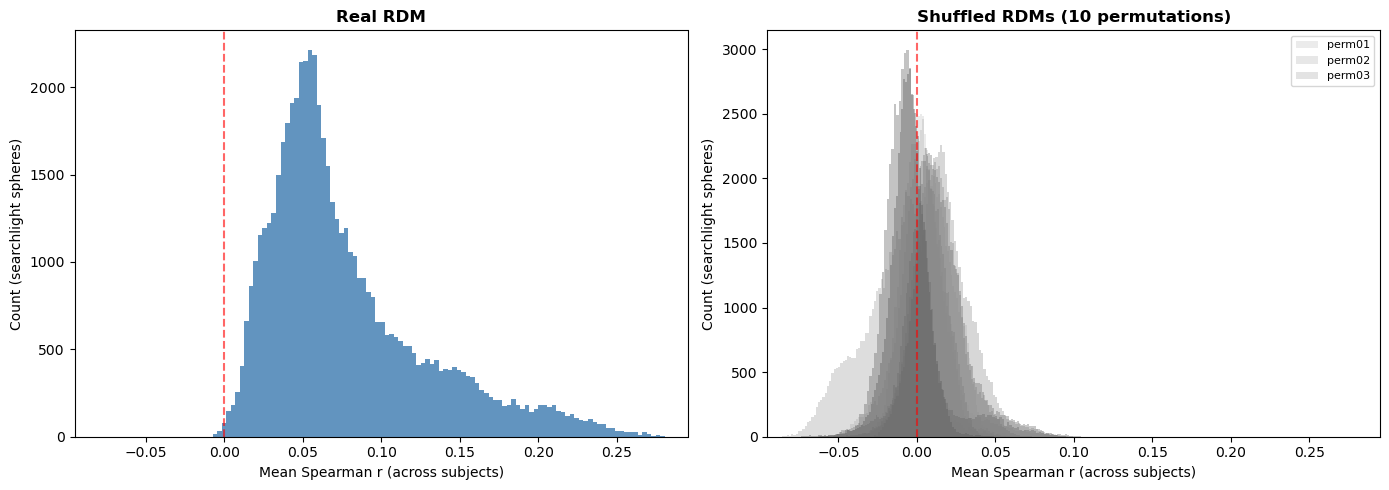

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real
real_mean_r = real_eval_scores.mean(axis=0)
axes[0].hist(real_mean_r, bins=100, color='steelblue', alpha=0.85, edgecolor='none')
axes[0].set_title('Real RDM', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Spearman r (across subjects)')
axes[0].set_ylabel('Count (searchlight spheres)')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.6)

# All permutations overlaid
colors = plt.cm.Greys(np.linspace(0.3, 0.7, N_PERMUTATIONS))
for p_i in range(N_PERMUTATIONS):
    perm_name = f'CLIP_AI_desc_perm{p_i+1:02d}'
    perm_scores = np.load(os.path.join(PERM_DIR, f'20sub_SL_eval_{perm_name}.npy'))
    perm_mean_r = perm_scores.mean(axis=0)
    axes[1].hist(perm_mean_r, bins=100, color=colors[p_i], alpha=0.4, edgecolor='none',
                 label=f'perm{p_i+1:02d}' if p_i < 3 else None)

axes[1].set_title(f'Shuffled RDMs ({N_PERMUTATIONS} permutations)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean Spearman r (across subjects)')
axes[1].set_ylabel('Count (searchlight spheres)')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.6)
axes[1].legend(fontsize=8, loc='upper right')

# Match x-axis
xlim = (min(axes[0].get_xlim()[0], axes[1].get_xlim()[0]),
        max(axes[0].get_xlim()[1], axes[1].get_xlim()[1]))
axes[0].set_xlim(xlim)
axes[1].set_xlim(xlim)

plt.tight_layout()
plt.savefig(os.path.join(PERM_DIR, 'real_vs_shuffled_hist.png'), dpi=200)
plt.show()

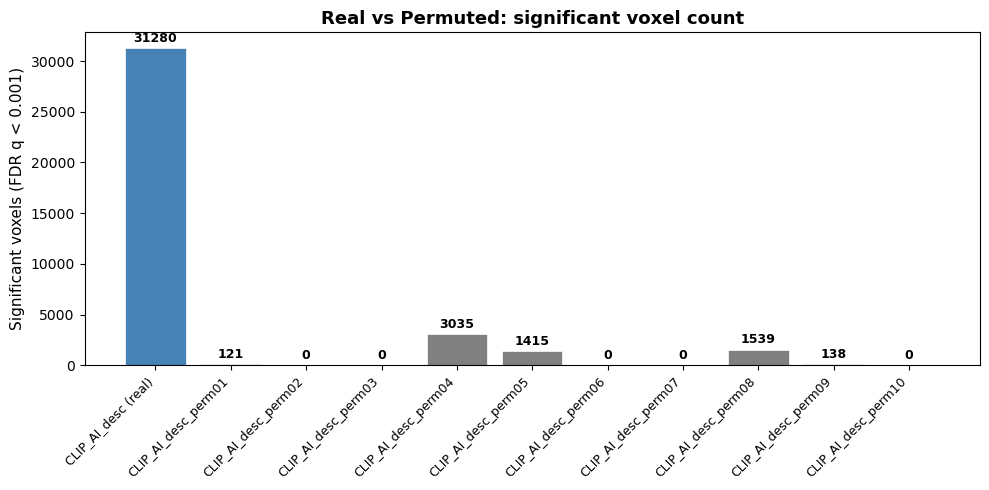

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

names = [r['name'] for r in rows]
n_sigs = [r['n_sig_voxels'] for r in rows]
colors_bar = ['steelblue'] + ['gray'] * N_PERMUTATIONS

ax.bar(range(len(names)), n_sigs, color=colors_bar, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Significant voxels (FDR q < 0.001)', fontsize=11)
ax.set_title('Real vs Permuted: significant voxel count', fontsize=13, fontweight='bold')

# Annotate counts
for i, v in enumerate(n_sigs):
    ax.text(i, v + max(n_sigs)*0.01, str(v), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PERM_DIR, 'real_vs_shuffled_sigvoxels.png'), dpi=200)
plt.show()

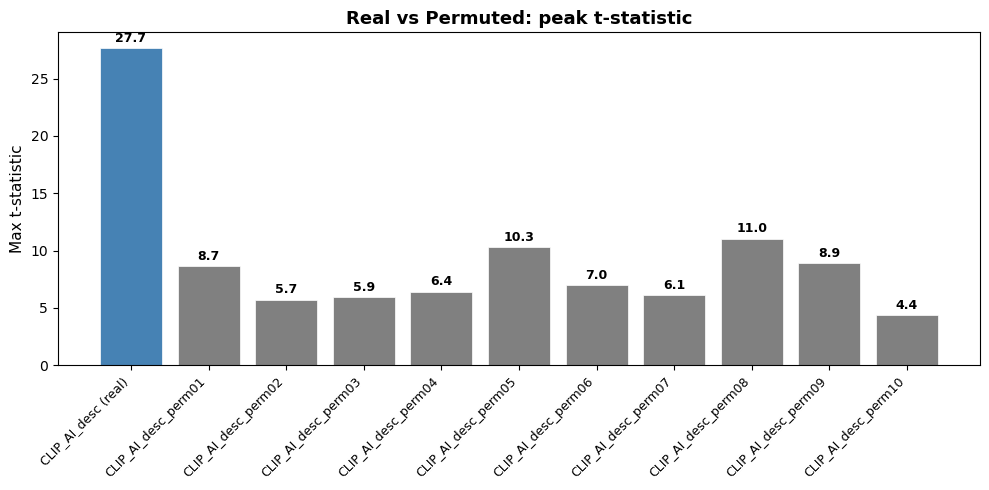

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

max_ts = [r['max_t'] for r in rows]

ax.bar(range(len(names)), max_ts, color=colors_bar, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Max t-statistic', fontsize=11)
ax.set_title('Real vs Permuted: peak t-statistic', fontsize=13, fontweight='bold')

for i, v in enumerate(max_ts):
    ax.text(i, v + max(max_ts)*0.01, f'{v:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(PERM_DIR, 'real_vs_shuffled_maxt.png'), dpi=200)
plt.show()

## 6. Visualize t-maps: real vs permutations

REAL:



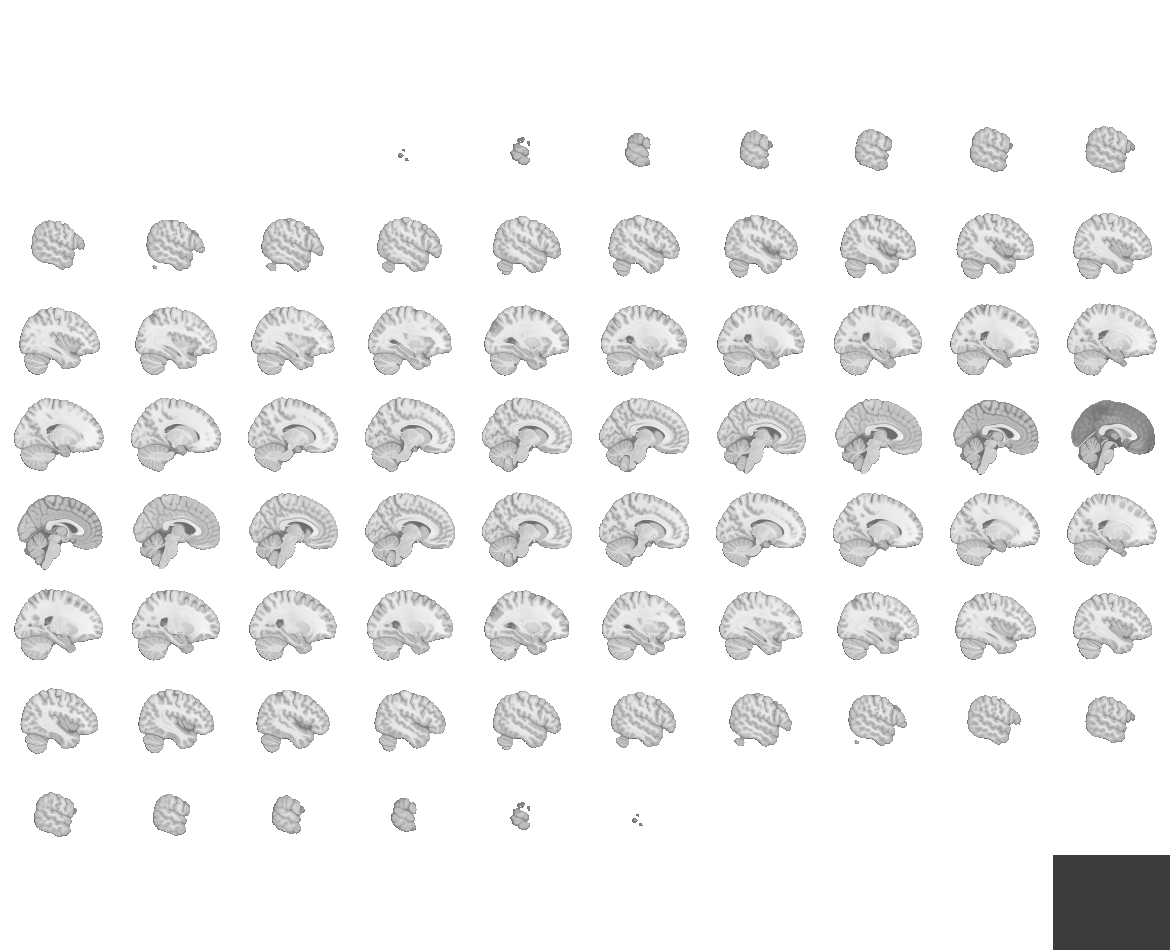
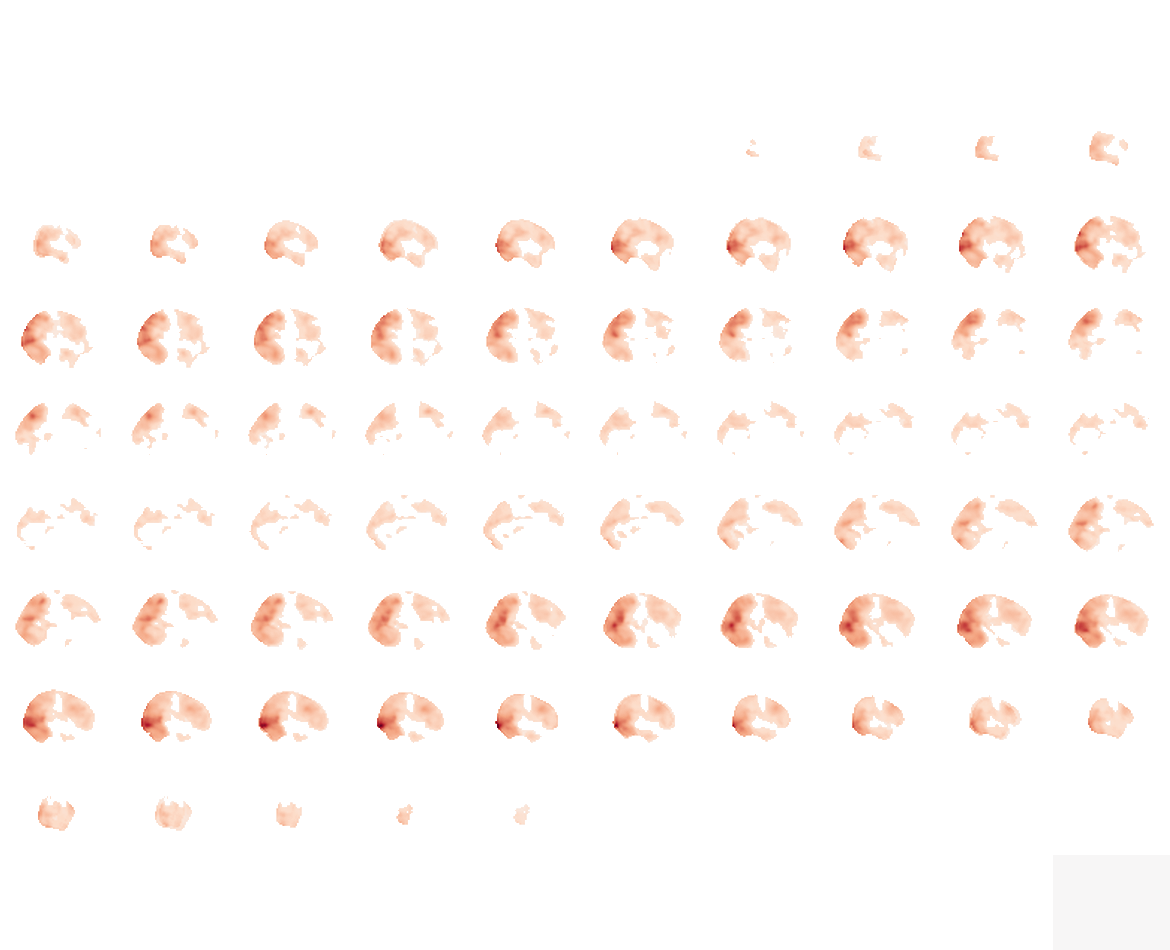

In [15]:
# Real t-map
print("REAL:")
view = plotting.view_img(real_tmap, draw_cross=False, black_bg=False, threshold=0,
                         title='CLIP_AI_desc (real)')
display(view)


CLIP_AI_desc_perm01:



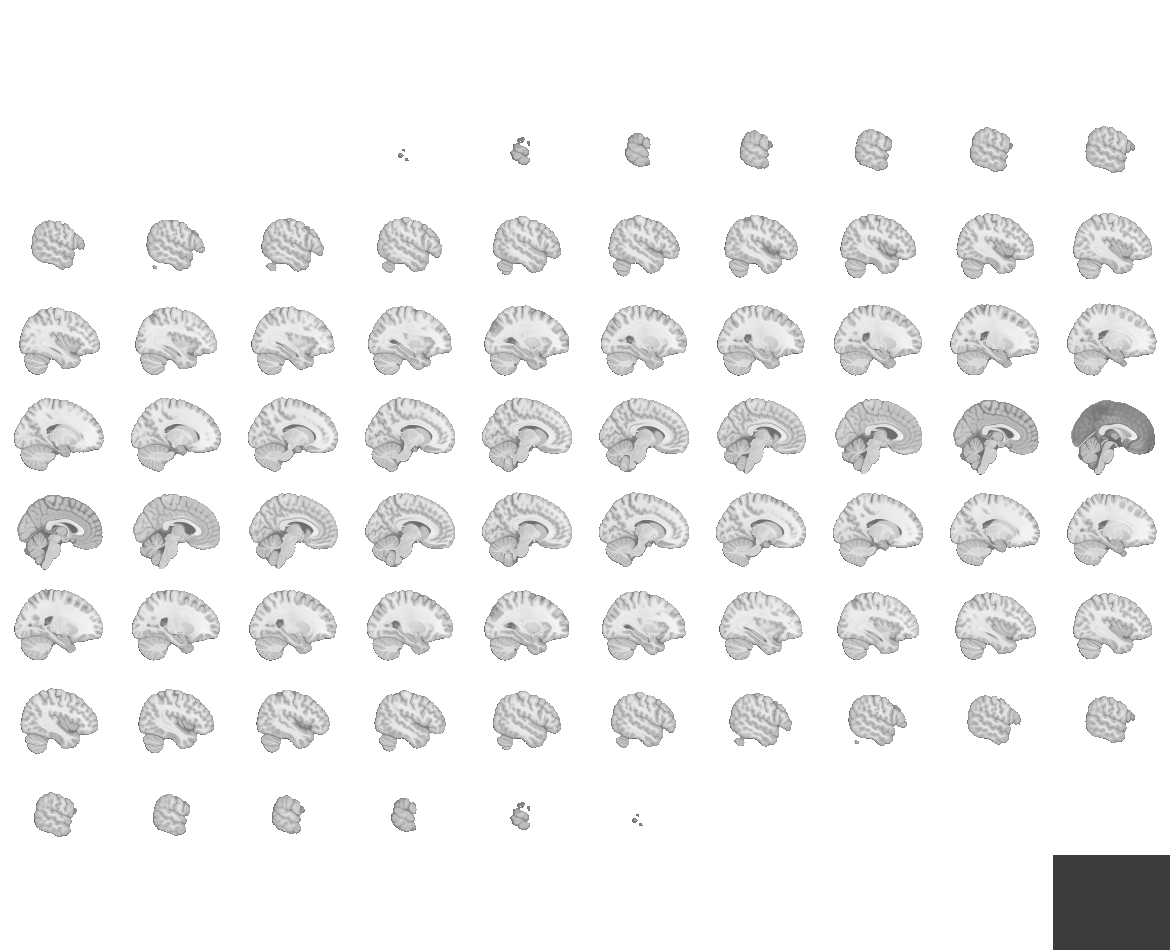
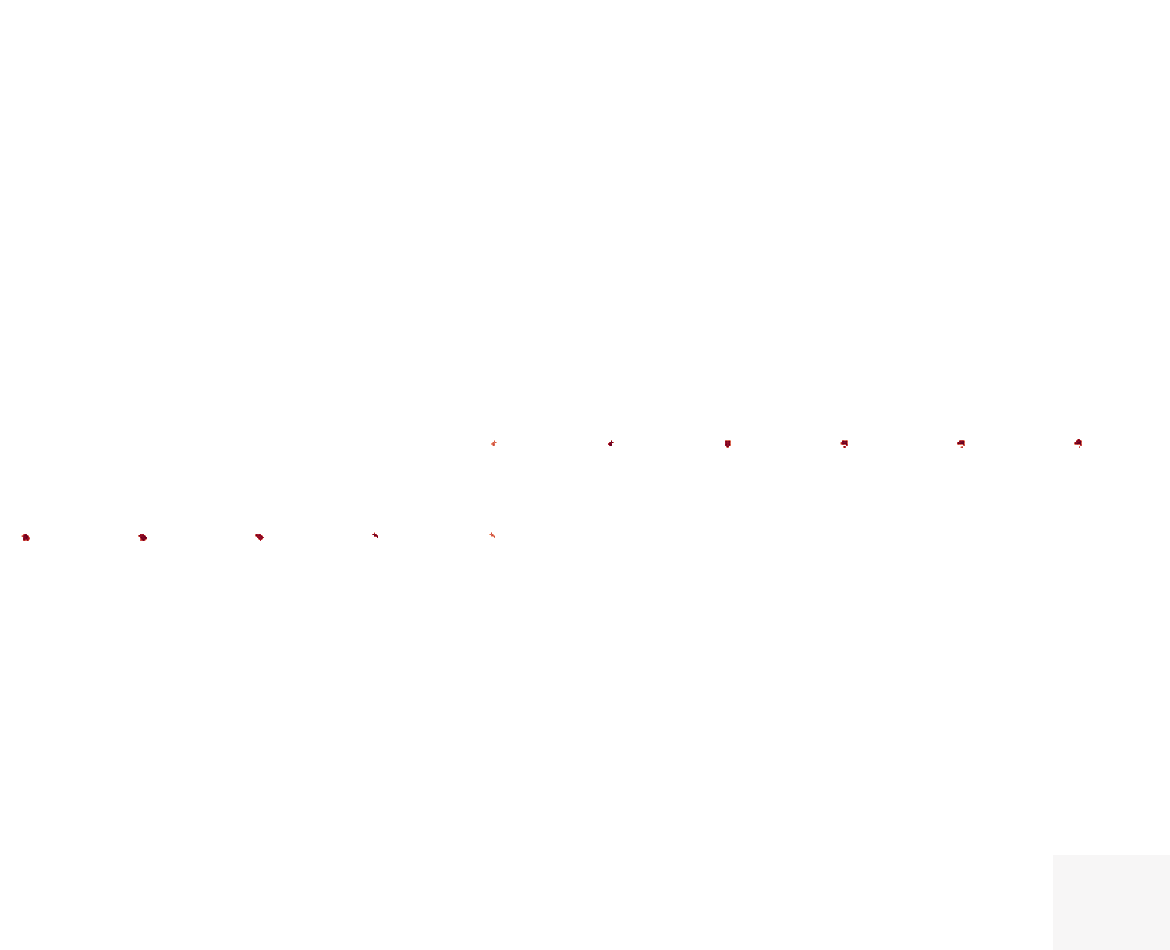


CLIP_AI_desc_perm02:


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_51316\3230766170.py:7: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  view = plotting.view_img(perm_tmap, draw_cross=False, black_bg=False, threshold=0,



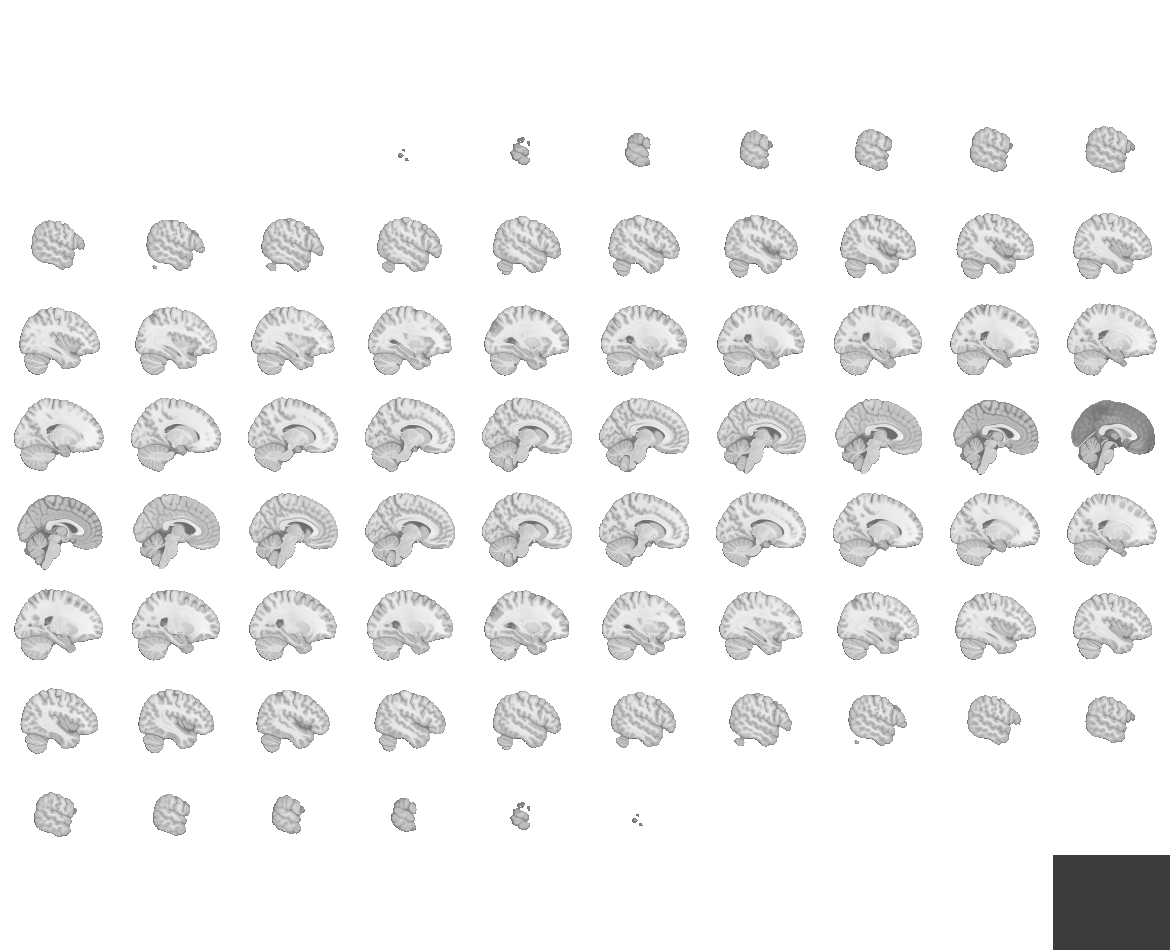
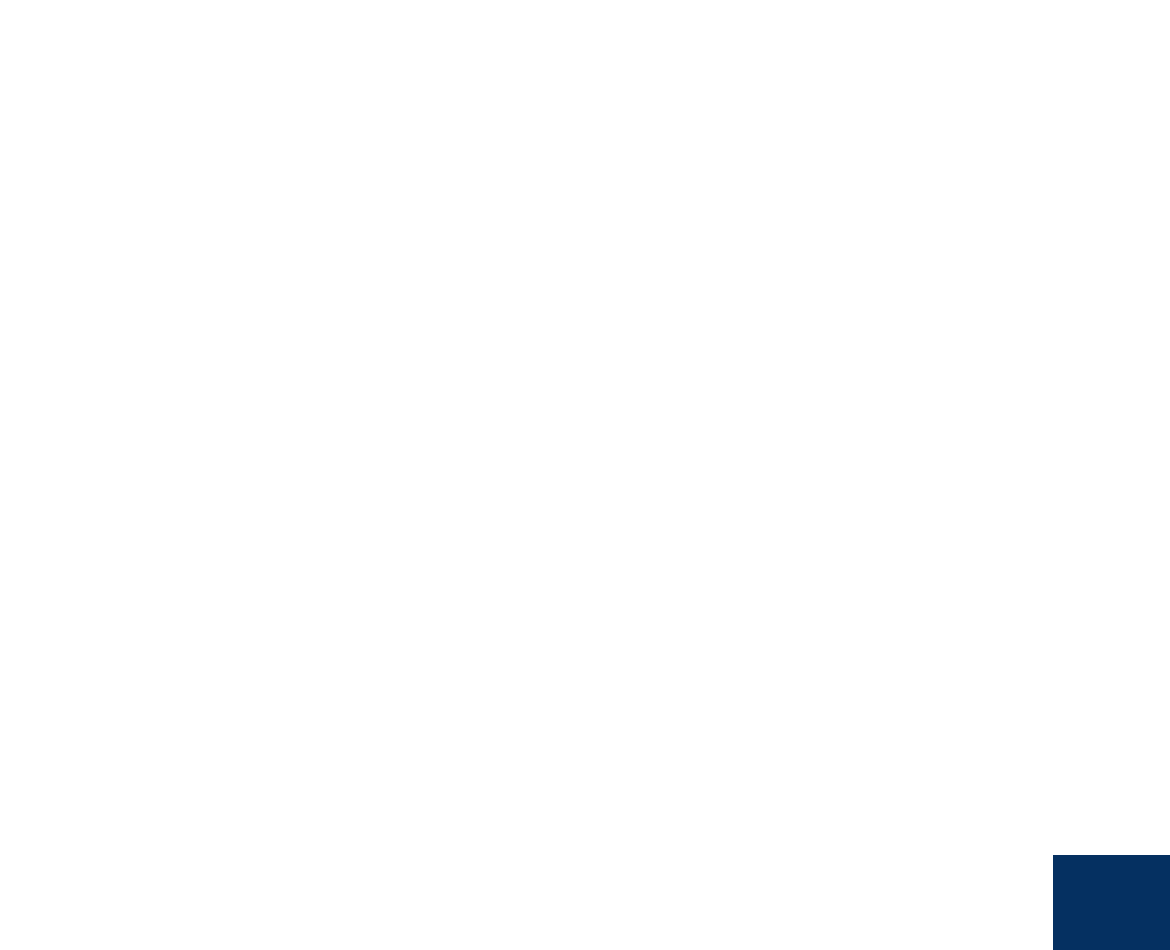


CLIP_AI_desc_perm03:


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_51316\3230766170.py:7: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  view = plotting.view_img(perm_tmap, draw_cross=False, black_bg=False, threshold=0,



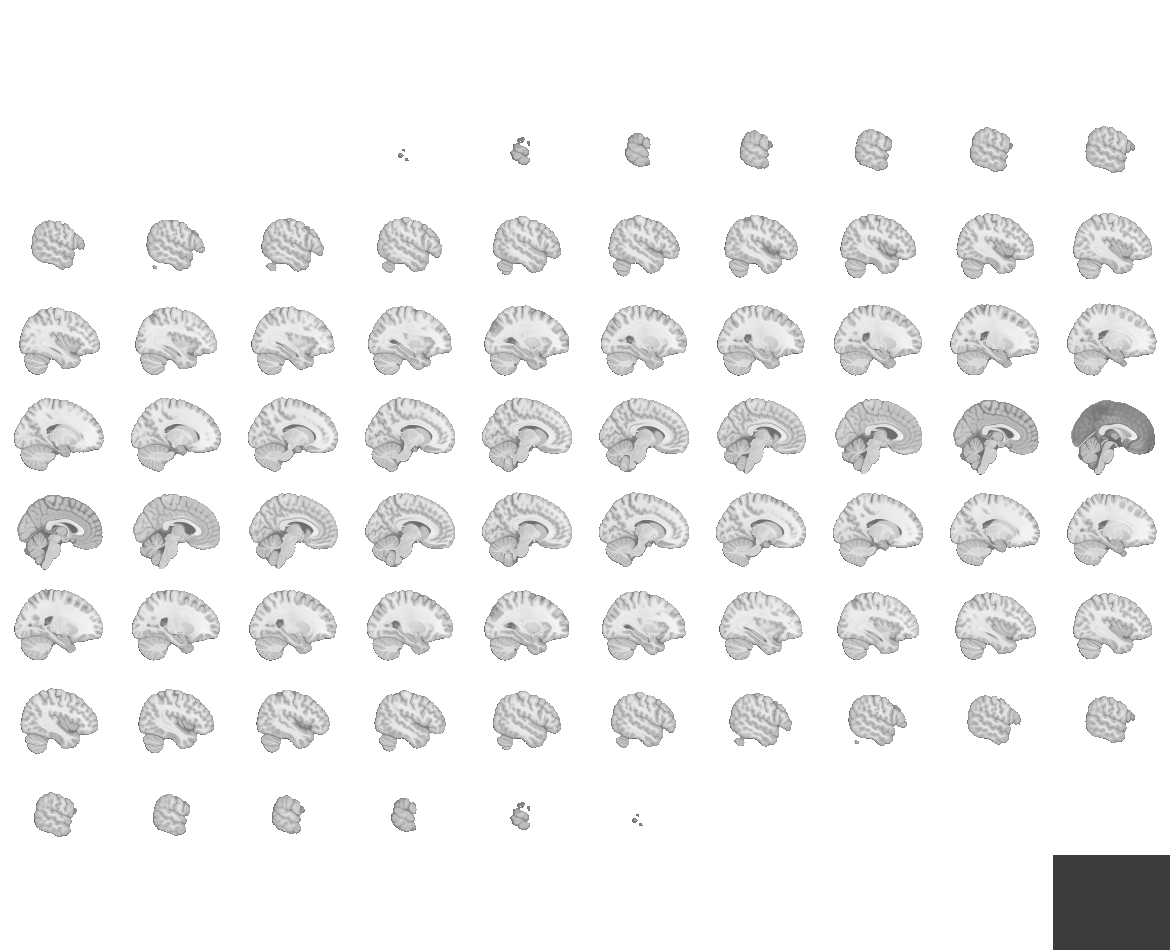
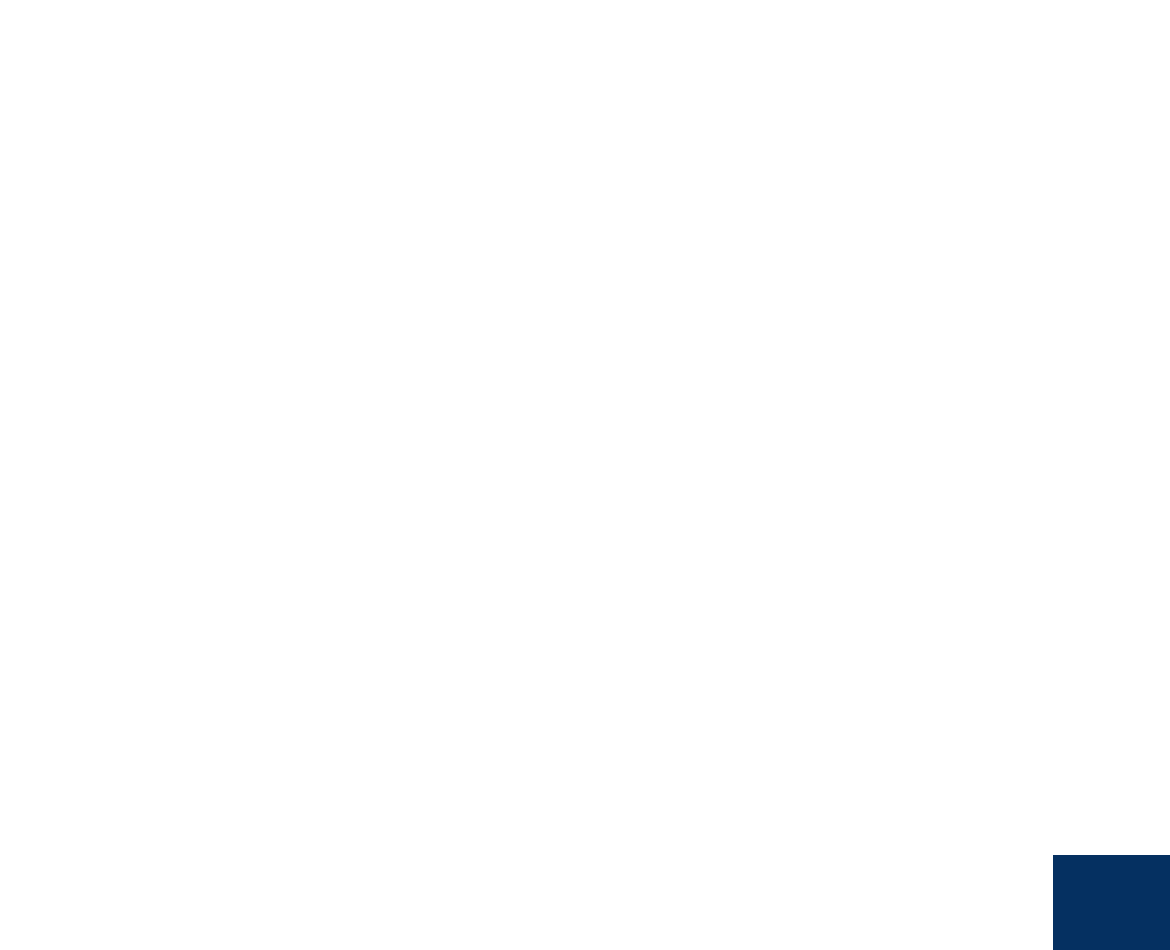


CLIP_AI_desc_perm04:



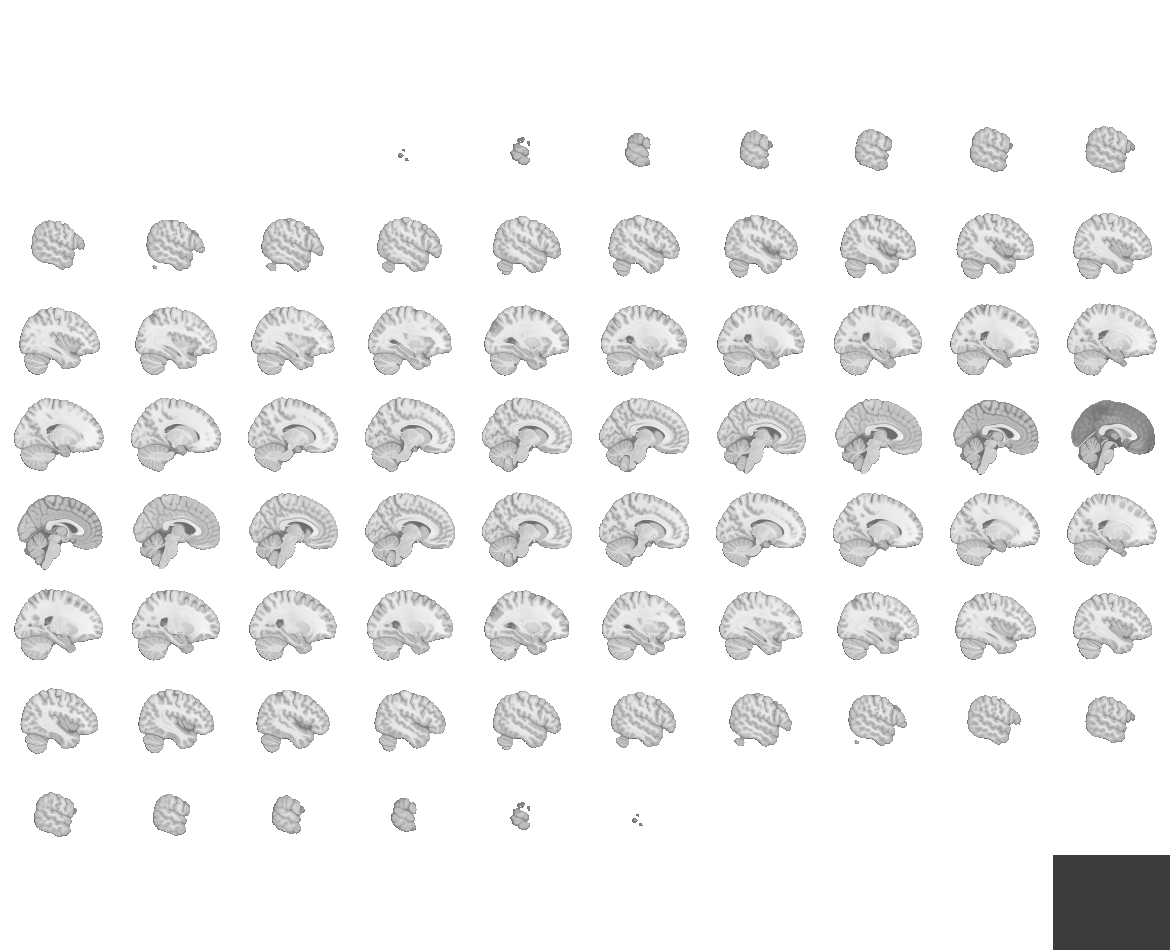
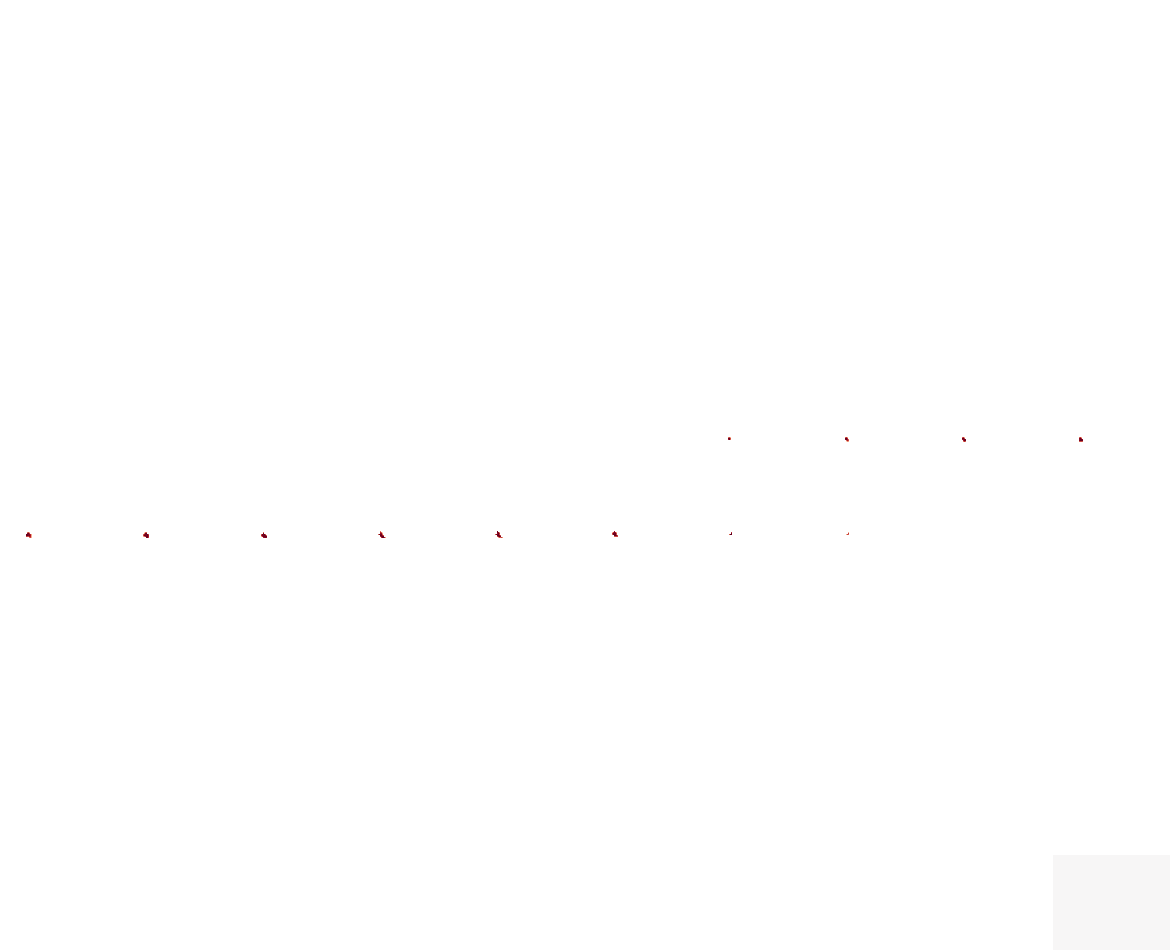


CLIP_AI_desc_perm05:



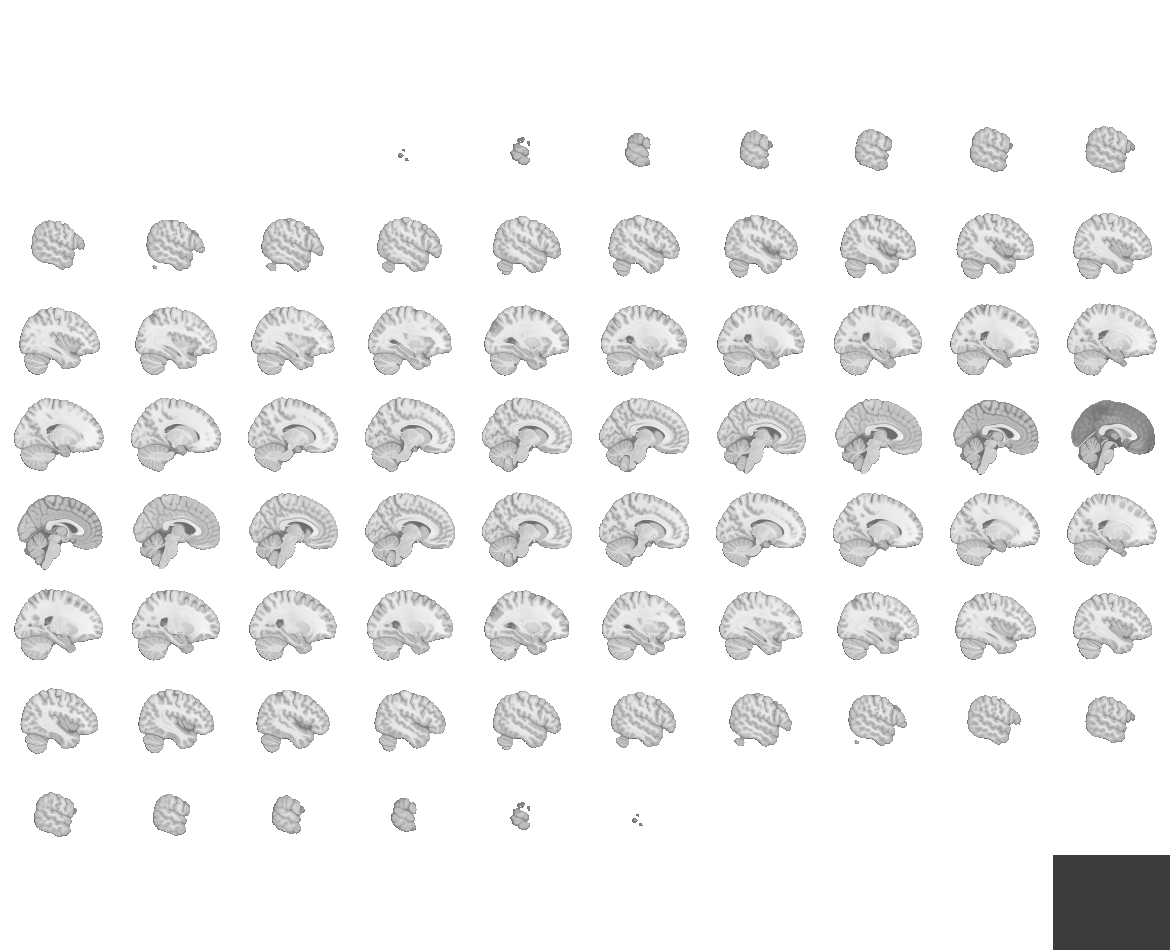
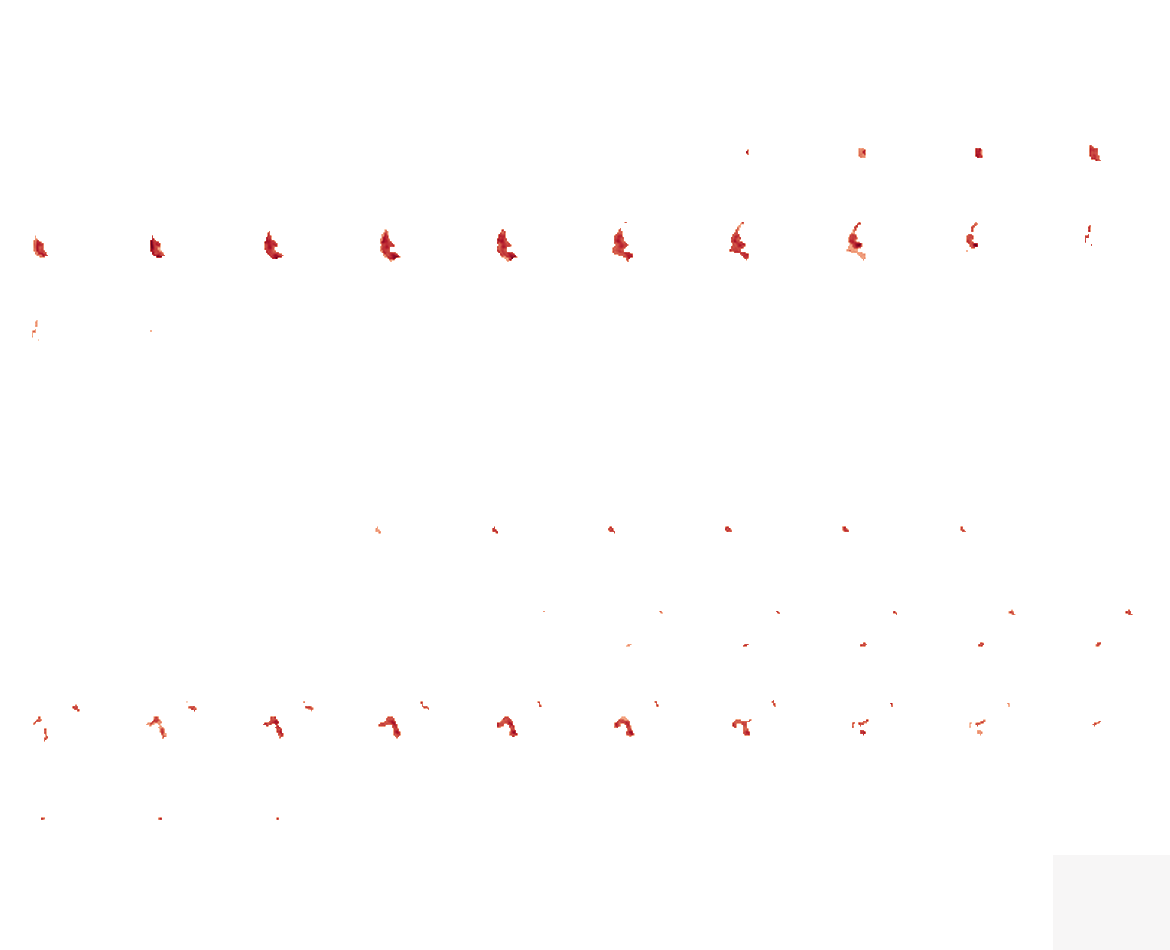


CLIP_AI_desc_perm06:


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_51316\3230766170.py:7: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  view = plotting.view_img(perm_tmap, draw_cross=False, black_bg=False, threshold=0,



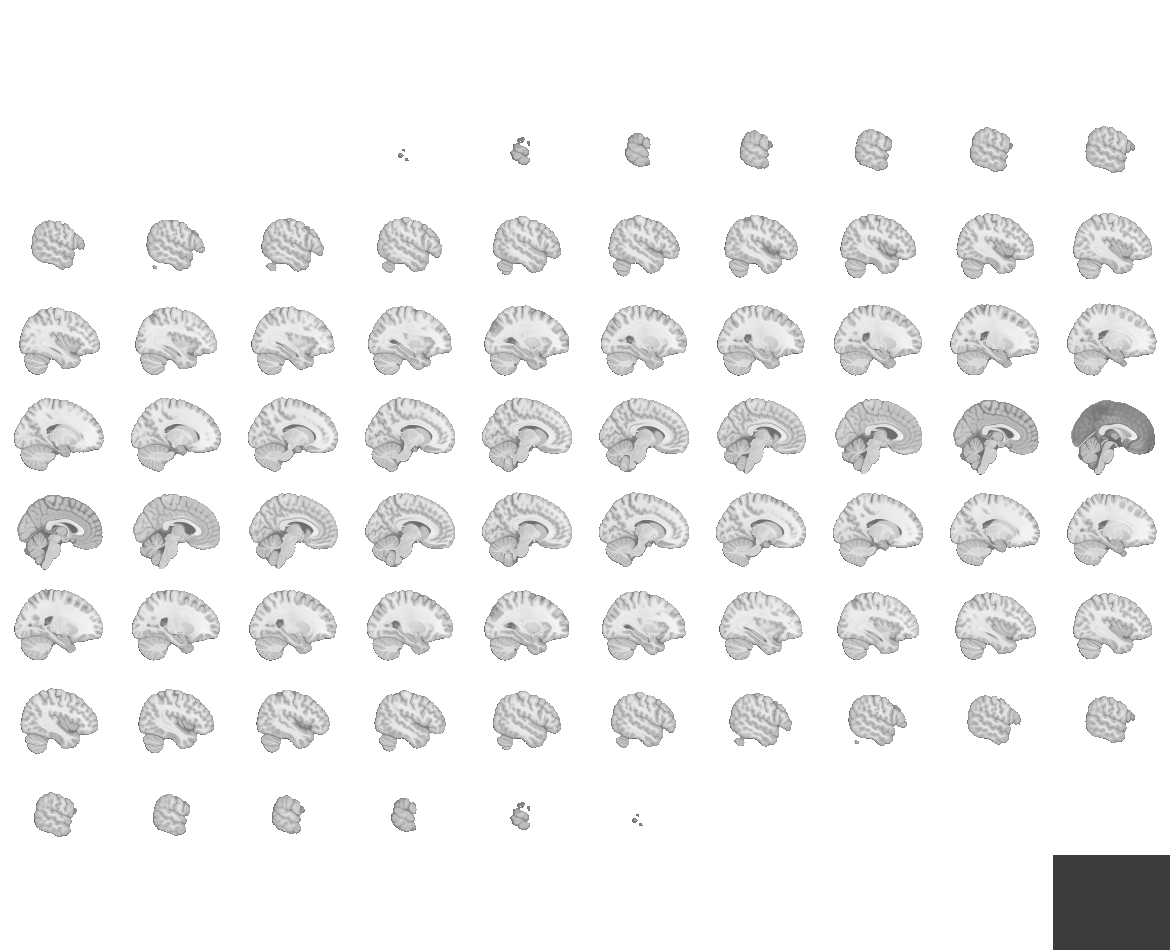
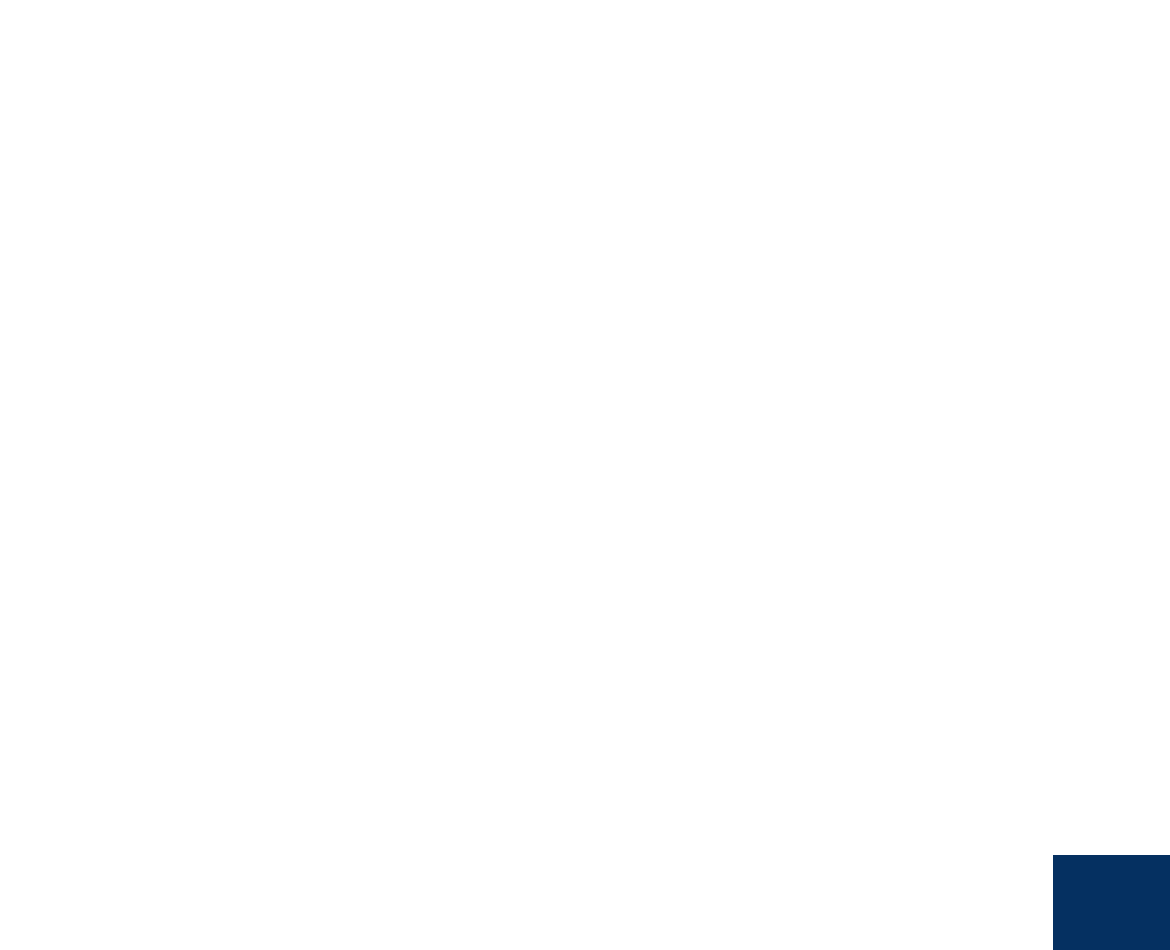


CLIP_AI_desc_perm07:


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_51316\3230766170.py:7: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  view = plotting.view_img(perm_tmap, draw_cross=False, black_bg=False, threshold=0,



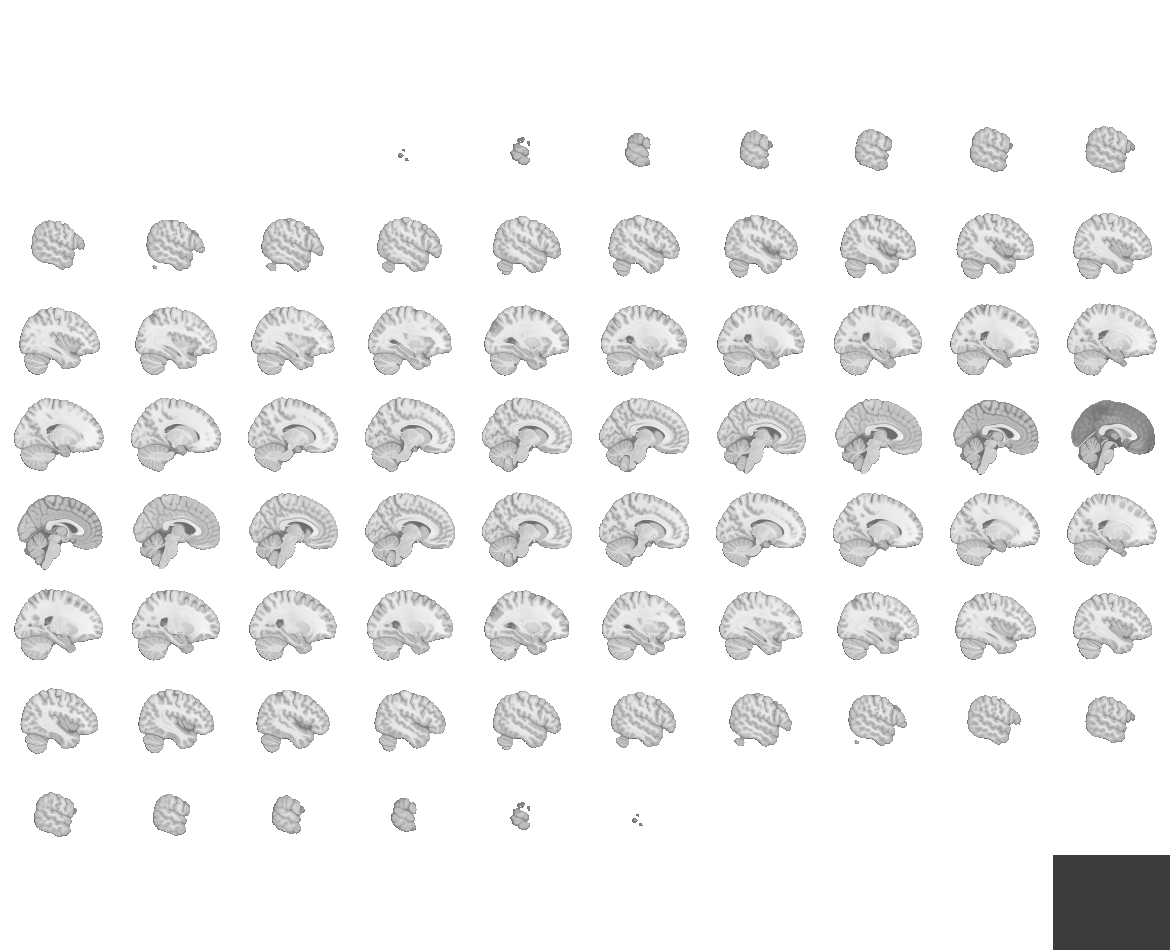
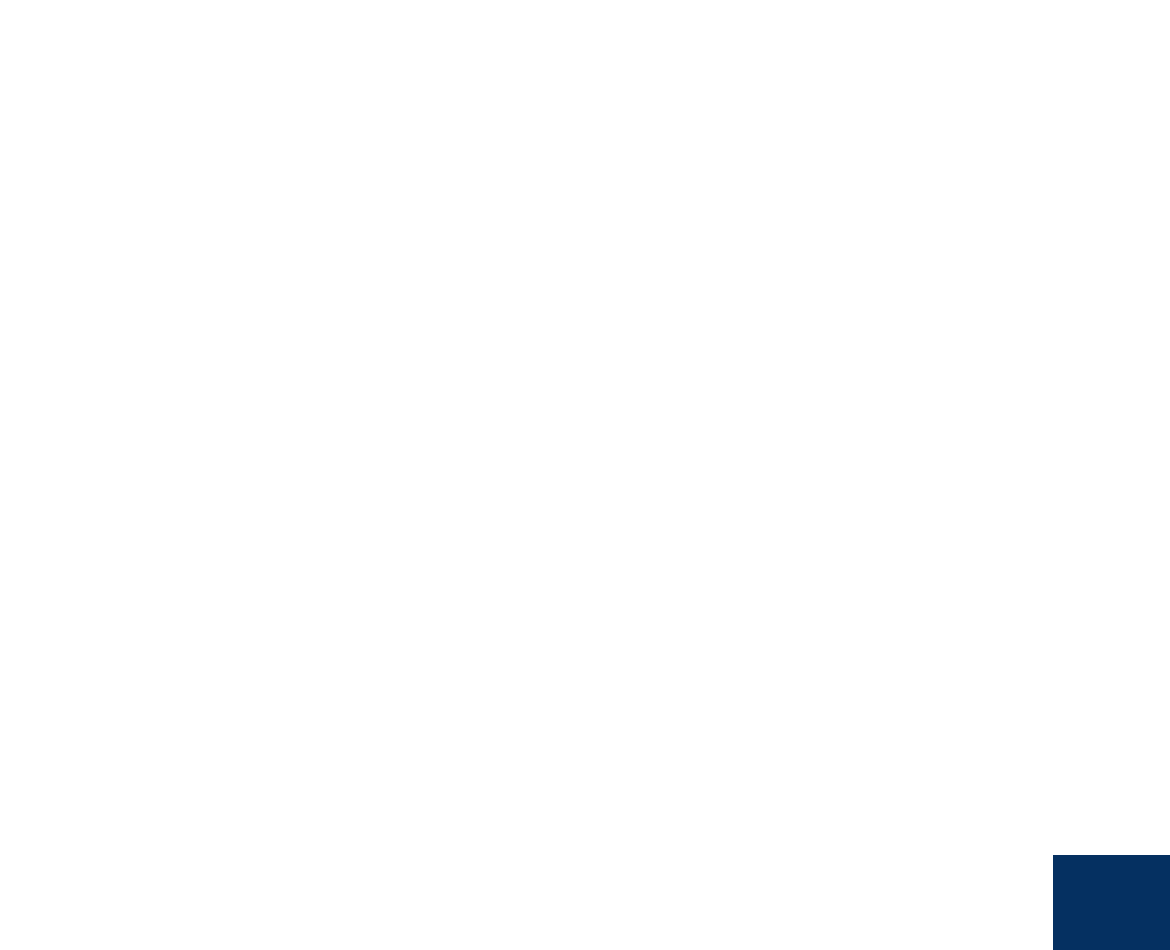


CLIP_AI_desc_perm08:



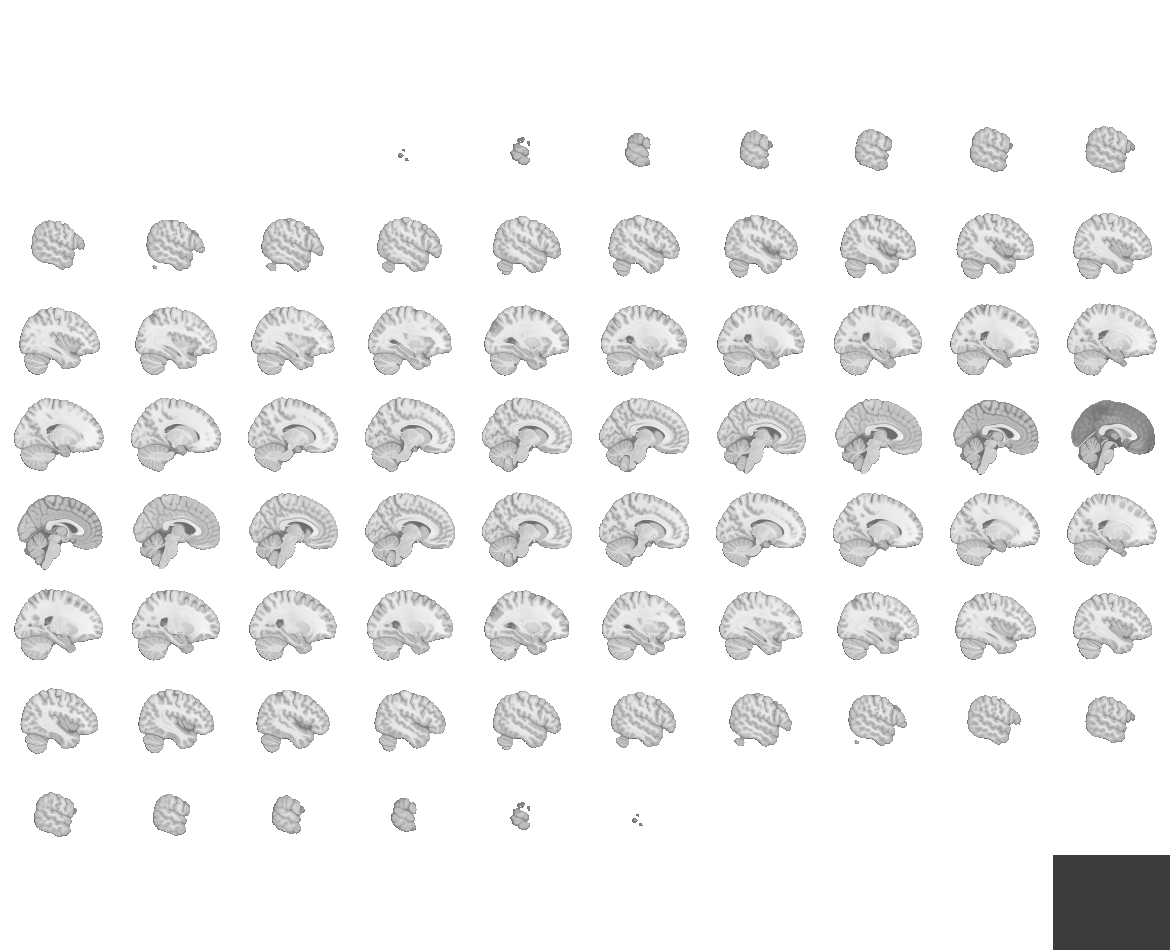
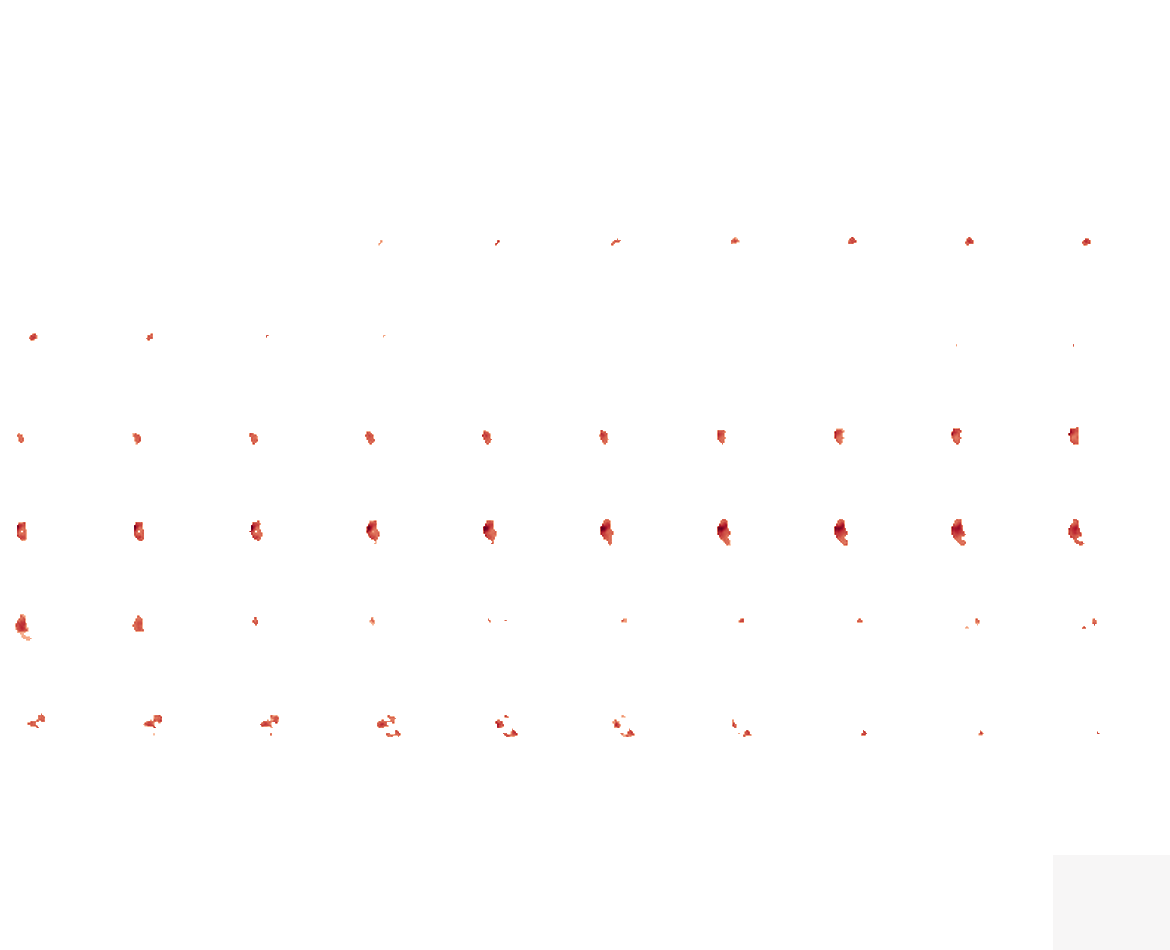


CLIP_AI_desc_perm09:



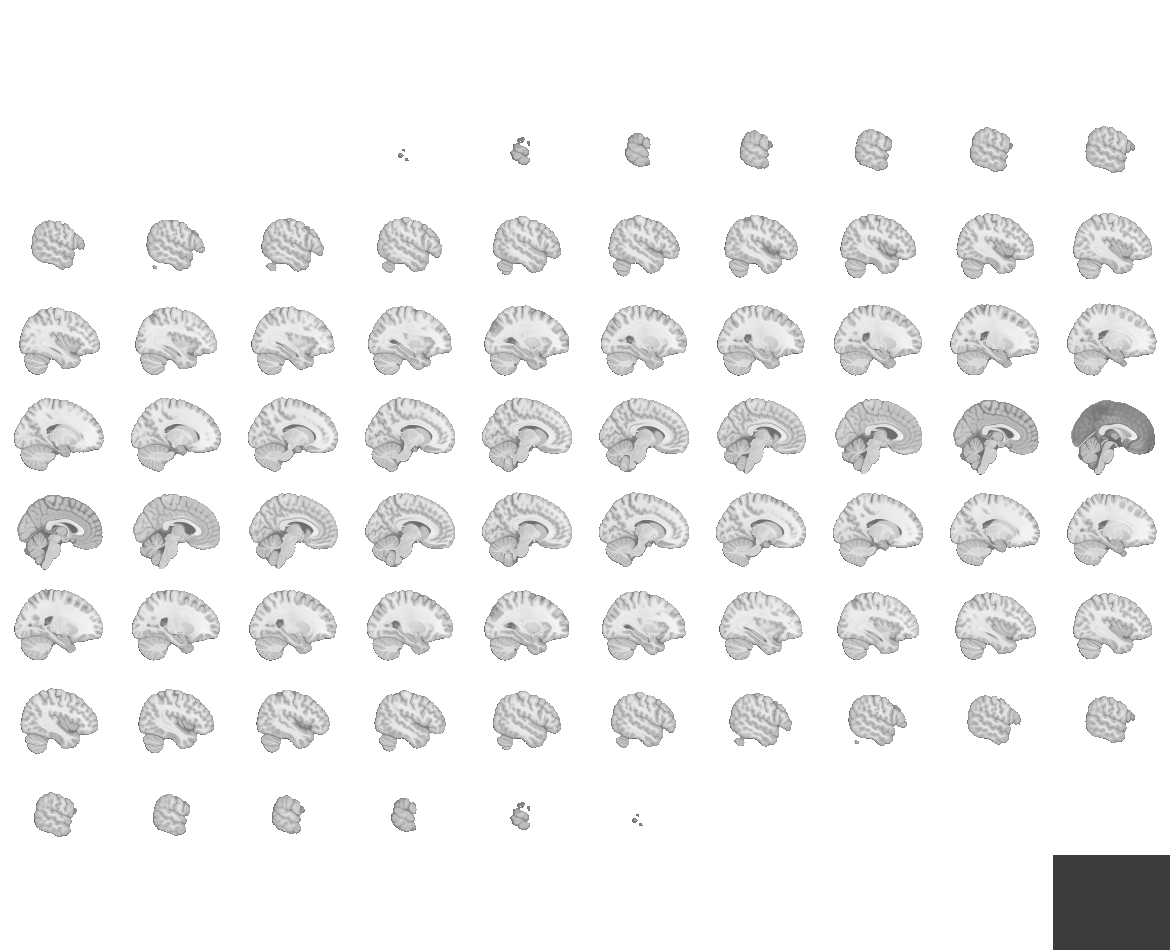
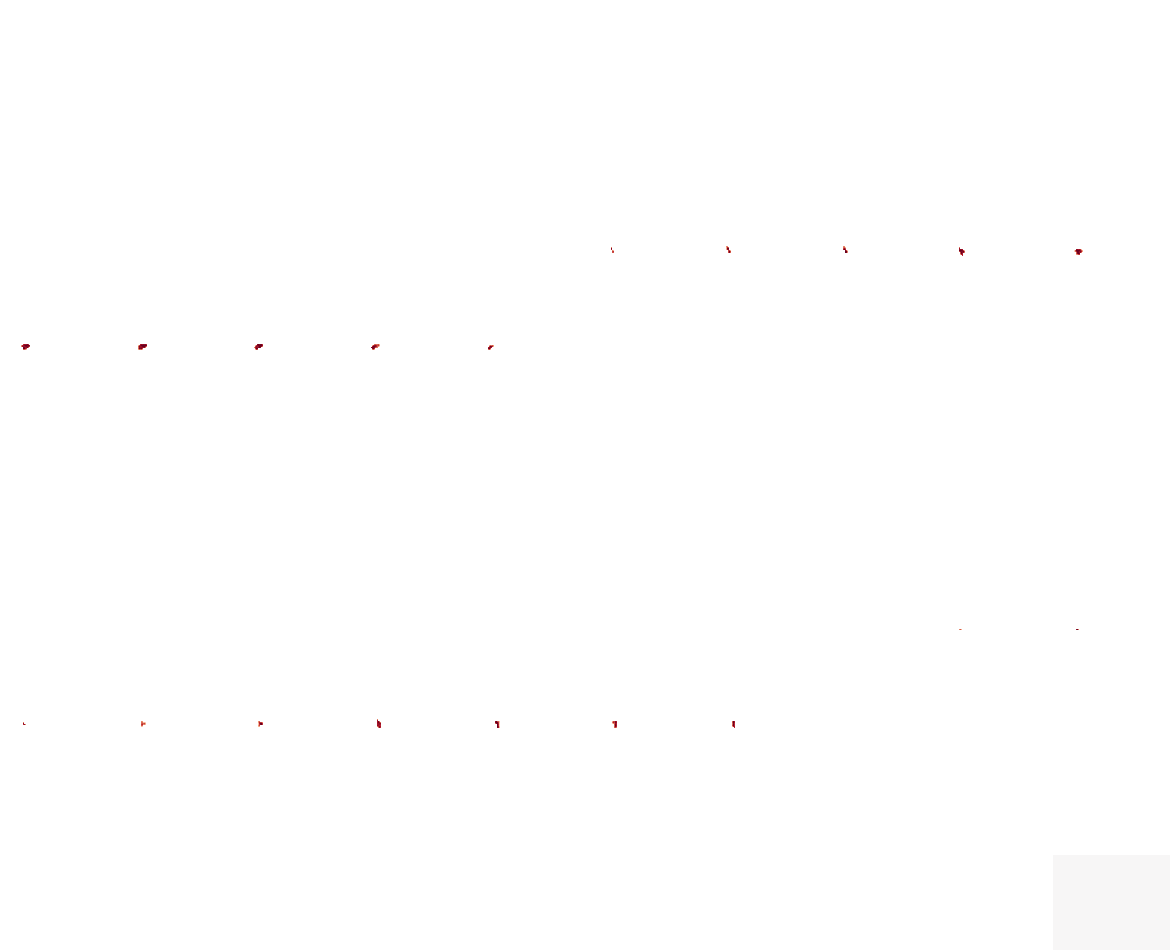


CLIP_AI_desc_perm10:


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_51316\3230766170.py:7: UserWarning: Given img is empty. Returning default cut_coords=(0.0, 0.0, 0.0) instead.
  view = plotting.view_img(perm_tmap, draw_cross=False, black_bg=False, threshold=0,



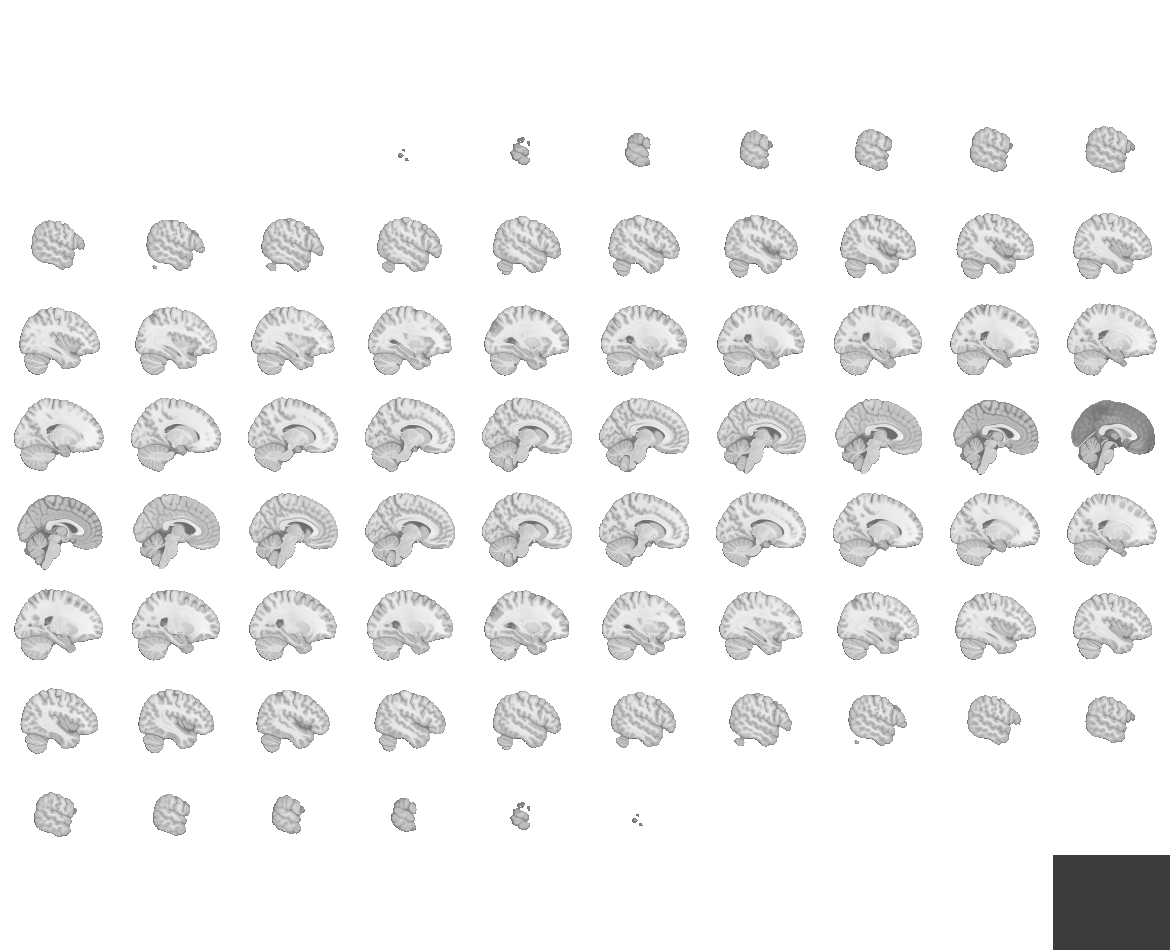
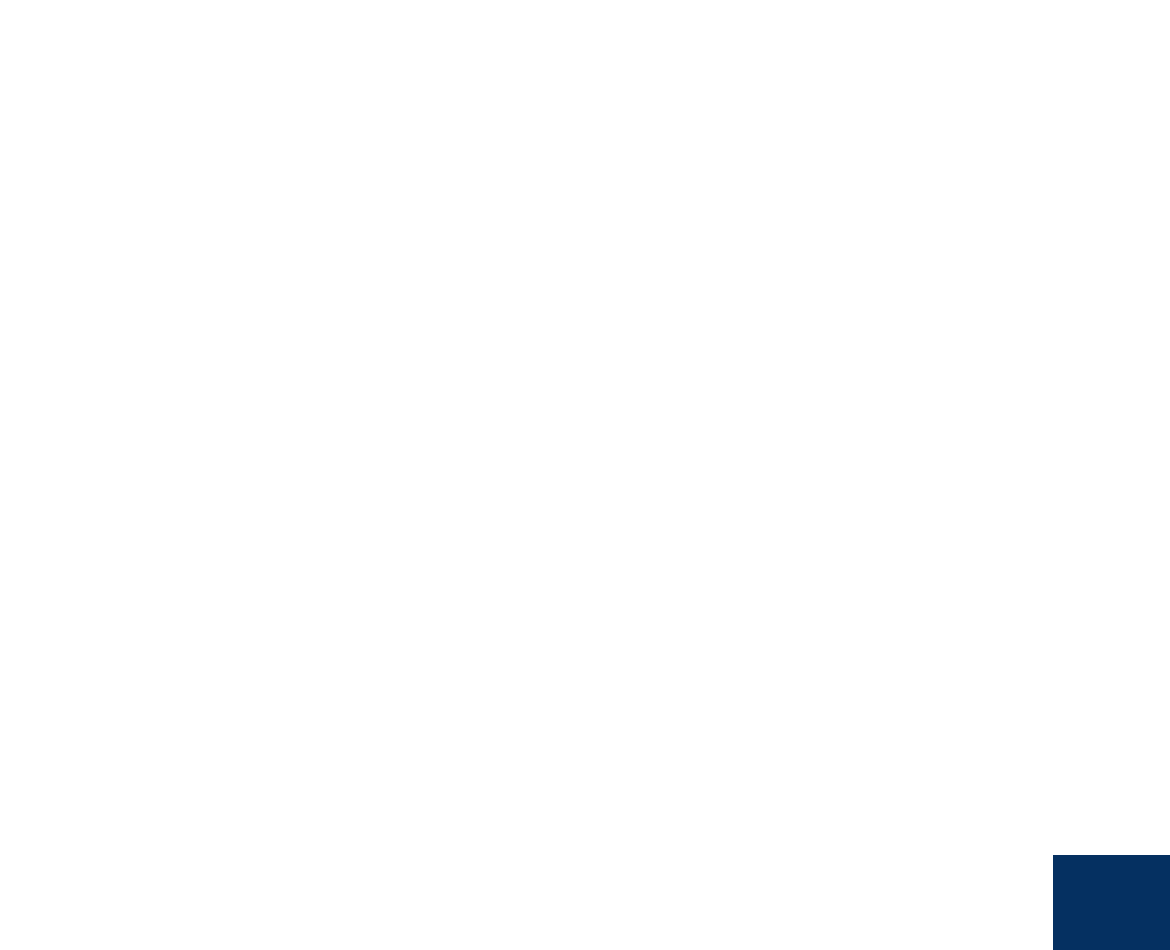

In [16]:
# Permutation t-maps
for p_i in range(N_PERMUTATIONS):
    perm_name = f'CLIP_AI_desc_perm{p_i+1:02d}'
    perm_tmap_path = os.path.join(PERM_DIR, f'tmap_{perm_name}_fdr001.nii.gz')
    perm_tmap = nib.load(perm_tmap_path)
    print(f"\n{perm_name}:")
    view = plotting.view_img(perm_tmap, draw_cross=False, black_bg=False, threshold=0,
                             title=f'{perm_name} (shuffled)')
    display(view)